---
title: "Building a Word Embeddings Model"
date: "2016-11-28"
categories: [nlp]
slug: "20161128-word-embeddings"
description: "Word embeddings turn text into vectors that encode meaning. I walk through building one from scratch using TensorFlow and the Gutenberg Encyclopedia."
---




One of the reasons why I find Natural Language Processing interesting is that it provides you with ways to turn textual data into a numeric representation, which allows you to do comparisons and find associations between words and their context. Its very intriguing how some of these representations encode semantic meaning, and how with mathematical operation we can decompose them and get insights on how we think and communicate.

Word embeddings are one of the relatively new methods for generating numeric word representations. Here I'll go over the process of defining what they are and how we can generate them.

## What are Word Embeddings?

In most machine learning tasks images and audio data have dense vector representations that describe their properties, such as the RGB distribution over pixels or the sonic properties of a recording. These representations allow us to directly compare and rank observations in terms of similarity, so one can find images that have similar amounts of *redness* or audio files sharing a similar rythmic structure. 

When working with language there is no obvious equivalent to these dense representations, so traditionally NLP encoding is done using arbitrary simbols that carry no specific information. To create a more meaningful representation one can use *distributional semantics*,  which relies on the assumption that words that appear in the same context must share semantic meaning.

One way to do this is via *latent semantic analysis* (LSA), a count-based method where results come from estimating how often words co-occur in a large corpus. An alternative approach is to build a neural network, where we derive vector representations of words that allow us to maximize a specific objective function, like predicting the next word in a sequence.

Visually the neural network looks like this:

![softmax](/images/softmax_classifier.png)

The goal is to create a model capable of predicting the most probable word $w_t$ given a context $h$. If we derive an informative vector representation of our words, we can use the softmax function to model this probability distribution:

$P(w_t \space | \space h) = softmax(score(w_t, h))$

Where the score is the compatibility of the word $w_i$ with the context $h$, meassured as their dot product:

$score(w_t \space | \space h) = w_t \cdot h$

This means that words that occur in similar contexts will have similar vector representation. For example, in a context made up of the words $[president,\space state,\space senate]$, terms like $government$ and $nation$ will receive simiar scores.

The explicit probability distribution looks like this:

$P(w_i \space | \space h) = \frac{\displaystyle \exp \{w_t \cdot h\}}{\displaystyle \sum_{j=1}^n{\exp \{w_j \cdot h\}}}$

We can express it in terms of its log likelihood, which our model will try to maximize:

$\displaystyle \mathcal{L} = (w_t \cdot h) - log\left(\sum_{j=1}^n{\exp \{w_j \cdot h\}}\right)$

Unfortunately calculating the last term from $\mathcal{L}$ is very expensive, as it involved going over all the words in the corpus hor each context. Being a well known problem, researchers have figured out several ways to approximate the softmax function. Word2vec uses the *negative sampling approach* and trains a logistic classifier to maximize the probability of $w_t$ given context $h$, against $k$ imaginary words $\tilde{w}$ in this same context. The idea is that we don't need the whole corpus to estimate a reasonable probability distribution for $w_t$, and maximizing against a couple of noise words should give good results. In these terms, the objective function is:

$\displaystyle \mathcal{K} = log \space Q_{\theta}(D = 1 \space | w_t, h) - \mathop{\mathbb{E}}_\tilde{w}[log \space Q_{\theta}(D = 0 \space | \tilde{w}, h)]$


Where $P(D = 1| w_t, h)$ is the probability that the pair $(w_t, h)$ came from our corpus $D$, and $Q$ is the logistic function with embedding parameters $\theta$. For example, if our corpus consists on the words "$the \space cat \space sits \space on \space the \space mat$", we are then interested in the $\theta$ that maximizes

$\displaystyle \mathcal{K} = log \space Q_{\theta}(D = 1 \space | cat, mat) - log \space Q_{\theta}(D = 0 \space | girl, mat)$

We find it by initializing the embeddings randomly, and then updating by taking small steps in direction of the likelihood's gradient $\frac{\partial}{\partial \theta} K$. After repeating this step many times the embedding matrix should converge.

## Getting Training Data
We will implement the algorithm described above using TensorFlow, but we need a source of training data. In this experiment I'll use the *The Project Gutenberg's Encyclopedia*, which can be downloaded freely from the internet. The input corpus has a length of almost 750,000 words, but we will reduce it to the 7,000 most frequent ones, and label every other word with the token `_UNKNOWN_`.

In [3]:
url = 'http://www.gutenberg.org/cache/epub/200/pg200.txt'
start = '*** START OF THIS PROJECT GUTENBERG EBOOK THE PG ENCYCLOPEDIA, VOL 1 ***\r'
end = '*** END OF THIS PROJECT GUTENBERG EBOOK THE PG ENCYCLOPEDIA, VOL 1 ***\r'

In [6]:
import urllib2
import string
import numpy as np
import pandas as pd
from collections import deque
from collections import Counter
from nltk.corpus import stopwords
from nltk import stem
from nltk import pos_tag

vocabulary_size = 5000
stemmer = stem.PorterStemmer()

## Remove blank lines.
data = urllib2.urlopen(url).read()
book = [line for line in data.split("\n") if line != '\r']

## Remove file header and footer.
s = book.index(start)+1
e = book.index(end)
book = book[s:e]

## Split into unigram tokens.
lines = [line.split() for line in book]

words = [word for line in lines for word in line]

words = [word[0] for word in pos_tag(words, tagset='universal') if word[1] in['NOUN','NUM','VERB']]

words = [word.lower().translate(None, string.punctuation).decode('utf-8') for word in words]

## Remove stopwords.
words = [stemmer.stem(word) for word in words if word not in \
                      stopwords.words('english') + ['start_symbol','stop_symbol']]

## Get counts.
counts = [['_UNKNOWN_', -1]]
counts.extend(Counter(words).most_common(vocabulary_size - 1))

## Get vocabulary.
vocab = dict()
for word, _ in counts:
    vocab[word] = len(vocab)
    
r_vocab = dict(zip(vocab.values(), vocab.keys()))

## Replace unknown token in original data.
data = []
unk_count = 0

for word in words:
    if word in vocab:
        index = vocab[word]
        data.append(index)
    else:
        data.append(0)
        unk_count+=1
        
counts[0][1] = unk_count

Instead of providing all the input data to the model on each iteration, we will divide it in *minibatches*. This means that we will only provide 256 $(h, w_t)$ pairs at a time, and the model will try to optimize parameters with them. By doing this the computation time is significantly reduced, and the results are known to approximate the optimal ones over time.

To produce the $(h,w_t)$ pairs, we follow a *skipgram* approach:

`the cat sits on the mat`  
`w_t = 'cat'`  
`(h,w_t)`
`=> ('the','cat')`
`   ('sits','cat')`
`   ('on','cat')`
`   ('the','cat')`
`   ('mat','cat')`

In [7]:
def generate_batch(batch_size, skipgram, skip_window):
    ## Check congruency of parameters.
    global data_index
    assert batch_size % skipgram == 0
    assert skipgram <= 2 * skip_window
    
    ## Create batch and label placeholder.
    batch = np.ndarray(shape=(batch_size), dtype=np.int32)
    labels = np.ndarray(shape=(batch_size, 1), dtype=np.int32)
    
    ## Pick up elements for window.
    window = 2 * skip_window + 1 ## [skip_window target skip_window]
    buffer = deque(maxlen=window)
    for _ in range(window):
        buffer.append(data[data_index])
        ## Loop the marker of observed count.
        data_index = (data_index + 1) % len(data)
    
    ## Generate context/word pairs.
    for i in range(batch_size / skipgram):
        target = skip_window  ## The target label at the center of the buffer.
        targets_to_avoid = [ skip_window ]
        
        for j in range(skipgram):
            while target in targets_to_avoid:
                target = np.random.randint(0, window)
            targets_to_avoid.append(target)
            batch[i * skipgram + j] = buffer[skip_window]
            labels[i * skipgram + j, 0] = buffer[target]
        buffer.append(data[data_index])
        data_index = (data_index + 1) % len(data)
    return batch, labels

In [8]:
## Sample batch.
print [r_vocab[i] for i in data[1000:1008]]

data_index = 1000

batch, labels = generate_batch(batch_size=8, skipgram=2, skip_window=1)
for i in range(8):
    print(batch[i], r_vocab[batch[i]], '->', labels[i, 0], r_vocab[labels[i, 0]])

[u'born', u'constantinopl', u'1815', u'son', u'govern', u'enter', u'servic', u'countri']
(1155, u'constantinopl', '->', 1806, u'1815')
(1155, u'constantinopl', '->', 79, u'born')
(1806, u'1815', '->', 1155, u'constantinopl')
(1806, u'1815', '->', 56, u'son')
(56, u'son', '->', 1806, u'1815')
(56, u'son', '->', 46, u'govern')
(46, u'govern', '->', 56, u'son')
(46, u'govern', '->', 273, u'enter')


## Bulding the Model

The first step is to define the placeholder variables for the input contexts (`train_x`), the output words (`train_y`), and the embedding matrix (`embeddings`). We also define other parameters related to the general configuration of the model.

In [9]:
import tensorflow as tf

batch_size = 512
embedding_size = 256
skip_window = 2 # How many words to consider left and right.
skipgram = 4 # How many times to reuse an input to generate a label.

## Initialize session.
sess = tf.InteractiveSession()
graph = tf.Graph()
graph.as_graph_def()

## Placeholders for inputs.
train_x = tf.placeholder(tf.int32, shape=[batch_size])
train_y = tf.placeholder(tf.int32, shape=[batch_size, 1])

## Embedding layer, initialized with uniform random values.
embeddings = tf.Variable(
    tf.random_uniform([vocabulary_size, embedding_size], -1.0, 1.0))

## Lookup table to match embedings to input data.
embed = tf.nn.embedding_lookup(embeddings, train_x)

Next, we define the *noise contrasting estimation* function, similar to the $\mathcal{K}$ we saw above. To minimize the total loss I'll use the Adam Optimizer, a version of gradient descend that calculates the optimal learning rates for the parameters.

In [10]:
neg_sample = 32 # Number of negative examples.

## On the noise-contrastive estimation loss, each word has a bias and weight.
## We initialize bias as zeros and weights sampled from the truncated normal dist.
nce_biases = tf.Variable(tf.zeros([vocabulary_size]))

nce_weights = tf.Variable(
    tf.truncated_normal([vocabulary_size, embedding_size],
                        stddev=1.0 / np.sqrt(embedding_size)))

## Compute the NCE loss, using a sample of the negative labels each time.
loss = tf.reduce_mean(
  tf.nn.nce_loss(nce_weights, nce_biases, embed, train_y,
                 neg_sample, vocabulary_size))

## Gradient descend optimizer.
optimizer = tf.train.AdamOptimizer().minimize(loss)

To evaluate how the model is performing over time, we can pick a sample of words and analyze their word embeddings. One interesting we can do with them is to look for other words with the most similar representation, which would be words with high probability of appearing in similar contexts.

In [11]:
test_size = 5 # Random set of words to evaluate similarity.
test_window = 100 # Pick test samples in the head of the distribution.

## Pick test words.
test_words = ['south', 'acid', 'church', 'countri', 'greek']
test_examples = [vocab[word] for word in test_words]
#test_examples = np.random.choice(test_window, test_size, replace=False)
test_dataset = tf.constant(test_examples, dtype=tf.int32)

print [r_vocab[w] for w in test_examples]

# Normalize embeddings for comparison.
norm = tf.sqrt(tf.reduce_sum(tf.square(embeddings), 1, keep_dims=True))
normalized_embeddings = embeddings / norm

valid_embeddings = tf.nn.embedding_lookup(normalized_embeddings, test_dataset)

## Calculate similarities with all other words.
similarity = tf.matmul(valid_embeddings, normalized_embeddings, transpose_b=True)

## Variable initializer.
init = tf.initialize_all_variables()

[u'south', u'acid', u'church', u'countri', u'greek']


Now we can start training the model. We feed 100,001 *minibatches* to the model and see how the error rate evolves over time.

In [12]:
data_index = 0
num_steps = 100001
avg_loss = 0
loss_hist = []

init.run()

for step in xrange(num_steps):
    batch_x, batch_y = generate_batch(batch_size, skipgram, skip_window)
    feed_dict = {train_x : batch_x, train_y : batch_y}

    ## Evaluate the optimizer on the NCE and update the parameters.
    _, loss_val = sess.run([optimizer, loss], feed_dict=feed_dict)
    avg_loss += loss_val

    ## Calculate the average loss over time.
    if step % 4000 == 0:
        if step > 0:
            avg_loss /= 4000
        if step % 20000 == 0:
            print 'Average loss at step %i: %f' %(step, avg_loss)
        loss_hist.append(avg_loss)
        avg_loss = 0

    #Every 20000 iterations find similar words to the test ones.
    if step % 100000 == 0:
        sim = similarity.eval()
        #print 'Step %i...' %step
        for i in xrange(test_size):
            sample_word = r_vocab[test_examples[i]]
            top_k = 5
            nearest = (-sim[i, :]).argsort()[1:top_k+1]
            log_str = "Nearest to %s:" % sample_word
            for k in xrange(top_k):
                close_word = r_vocab[nearest[k]]
                log_str = "%s %s," % (log_str, close_word)
            print(log_str)
final_embeddings = normalized_embeddings.eval()
#sess.close()

Average loss at step 0: 110.395996
Nearest to south: pisa, proport, small, accept, orthodox,
Nearest to acid: adher, sc, impress, diamond, 1905,
Nearest to church: detach, cattl, encount, propag, break,
Nearest to countri: consecr, lion, archbishop, purchas, fast,
Nearest to greek: conform, romain, copenhagen, madeira, kent,
Average loss at step 20000: 6.177050
Average loss at step 40000: 5.999347
Average loss at step 60000: 5.894408
Average loss at step 80000: 5.640916
Average loss at step 100000: 5.618031
Nearest to south: _UNKNOWN_, north, west, countri, saskatchewan,
Nearest to acid: _UNKNOWN_, dilut, potassium, dioxid, alkali,
Nearest to church: _UNKNOWN_, cathedr, anglican, countri, cathol,
Nearest to countri: _UNKNOWN_, time, peshawar, south, district,
Nearest to greek: _UNKNOWN_, slavon, time, manual, alchemi,


## Visualizing the Results

In the output above we can see how the model evolves over time. As the error rate drops and stabilizes, the model is able to find better representations with high probability of occuring in the same context. After processing 100,001 minibatches we see that *south* is very close to *north* and *west*, *church* to * cathedral*, *anglican* and *catholic*.

On the plots below we can see the closest neighbors to each of the test words, which in all cases make semantic sense.

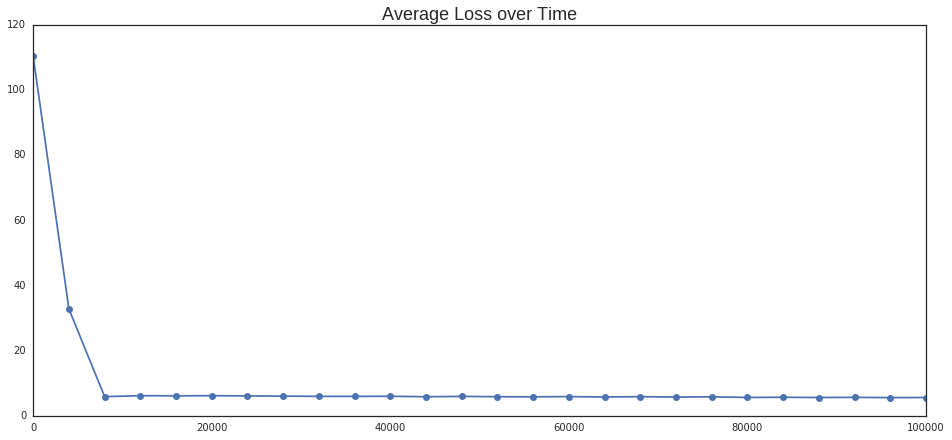

In [138]:
from tsne import bh_sne
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

%matplotlib inline
sns.set_style('white')
plt.rcParams['figure.figsize'] = (16.0, 7.0)

plt.plot(range(0, 100001, 4000) ,loss_hist, marker='o')
plt.title('Average Loss over Time', size=18);

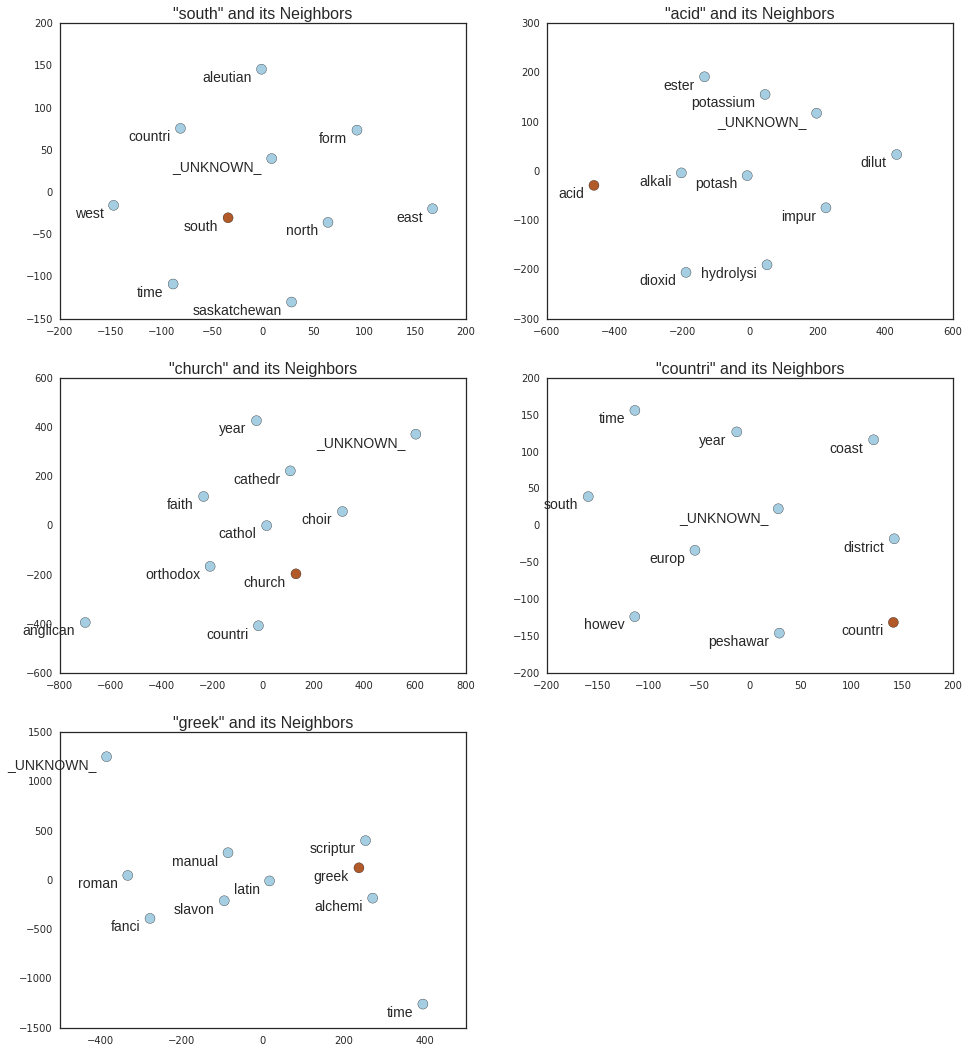

In [146]:
## Get words we want to plot.
plot_only = 500
tsne = TSNE(perplexity=8, n_components=2, init='pca', n_iter=5000)
low_dim_embs = tsne.fit_transform(final_embeddings[1:plot_only+1,:])

## Reduce their dimensionality, get sizes and labels.
word_viz = low_dim_embs#bh_sne(low_dim_embs, perplexity=8)
labels = [r_vocab[i] for i in xrange(1, plot_only+1)]
sizes = [np.sqrt(counts[i][1])+5 for i in xrange(1, plot_only+1)]

## Plot.
plt.rcParams['figure.figsize'] = (16.0, 18.0)
plt.figure(1)
f=0
for i in test_examples:
    ## Find neighbors.
    close_obs = (-sim[f, :]).argsort()[0:10]
    color_obs = np.append(1, np.zeros(len(close_obs)-1))
    
    ## Generate points and labels.
    word_viz = tsne.fit_transform(final_embeddings[close_obs,:])
    labels = [r_vocab[i] for i in close_obs]
    
    ## Make scatter plot.
    plt.subplot(321 + f)
    plt.title('"' + labels[0] + '" and its Neighbors', size=16)
    plt.scatter(word_viz[:, 0], word_viz[:, 1], s=100, c=color_obs, cmap='Paired')

    for label, x, y in zip(labels, word_viz[:, 0], word_viz[:, 1]):
         plt.annotate(label, 
                     xy = (x, y), xytext = (-10, -15), fontsize=14,
                     textcoords = 'offset points', ha = 'right', va = 'bottom')
    f+=1